In [1]:
from sys import path

path.append("..")

import os
from pathlib import Path

os.chdir(Path.cwd().parent)

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from src.graph_utils.reading import read_metadata
from src.settings import Settings


In [3]:
metadata = read_metadata()

In [4]:
from collections import Counter

def count_elements(row_array):
    if len(row_array) == 1 and row_array[0] == -1:
        return 0
    return len(row_array)

test_data = pd.read_parquet(Settings.processed_datasets_dir / 'table.parquet')
test_data['count'] = test_data['result'].apply(count_elements)

test_data['percentage'] = test_data.apply(lambda x: x['count'] / metadata[x['dataset_name']]['graph_count'], axis=1)

In [5]:
def rename_feature(feature):
    if feature.startswith("jaccard_index_normalized"):
        return feature.replace("jaccard_index_normalized", "jaccard_index", 1)
    elif feature.startswith("jaccard_index"):
        return feature.replace("jaccard_index", "common_neigbours", 1)
    return feature


test_data["features"].apply(
    lambda lst: [rename_feature(f) for f in lst]
).head(40)


0                                    [common_neigbours]
1                                       [jaccard_index]
2                                         [adamic_adar]
3                                          [katz_index]
4                               [neighborhood_distance]
5                                [neighborhood_measure]
6                             [preferential_attachment]
7                                 [resource_allocation]
8                                      [same_community]
9                                     [total_nieghbors]
10                                 [algebraic_distance]
11                                                [ari]
0                                                 [lds]
1                                                [scan]
2                                       [cn_quadrangle]
3                                         [cn_triangle]
4                                                 [lss]
5                             [simmelian_sparsif

In [5]:
test_data = test_data.reset_index(drop=True)
test_data

,features,dataset_name,result,count,percentage
0,[jaccard_index],graph5,"[2, 5, 3, 6, 8, 4, 10, 13, 20, 11, 12, 21, 9, ...",18,0.529412
1,[jaccard_index_normalized],graph5,"[2, 5, 3, 6, 8, 4, 10, 13, 20, 15, 26]",11,0.323529
2,[adamic_adar],graph5,"[2, 5, 3, 6, 8, 4, 10, 13, 20, 15, 26]",11,0.323529
3,[katz_index],graph5,"[2, 5, 3, 6, 8, 4, 10, 13, 20, 11, 12, 21, 9, ...",18,0.529412
4,[neighborhood_distance],graph5,"[2, 5, 3, 6, 8, 4, 10, 13, 20, 15, 26]",11,0.323529
...,...,...,...,...,...
6595,"[degree_centrality_normalized, degree_centrali...",sr361566,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",32548,1.000000
6596,"[katz_centrality, katz_centrality:k_graph2, ka...",sr361566,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",32548,1.000000
6597,"[lcc, lcc:k_graph2, lcc:k_graph3]",sr361566,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",32548,1.000000
6598,"[ldp_degree, ldp_degree:k_graph2, ldp_degree:k...",sr361566,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",32548,1.000000


In [6]:
test_data['result'].iloc[0]

array([ 2,  5,  3,  6,  8,  4, 10, 13, 20, 11, 12, 21,  9, 19, 16, 24, 15,
       26])

In [7]:

test_data['features'] = test_data['features'].astype('string').astype('category')
test_data.columns

Index(['features', 'dataset_name', 'result', 'count', 'percentage'], dtype='object')

In [8]:
test_data.sort_values('count').head(20)

,features,dataset_name,result,count,percentage
4793,['closeness_normalized' 'closeness_normalized:...,highlyirregular11,[-1],0,0.0
5974,['neighborhood_distance' 'neighborhood_distanc...,selfcomp9,[-1],0,0.0
5973,['katz_index' 'katz_index:k_graph2' 'katz_inde...,selfcomp9,[-1],0,0.0
5972,['adamic_adar' 'adamic_adar:k_graph2' 'adamic_...,selfcomp9,[-1],0,0.0
5971,['jaccard_index_normalized' 'jaccard_index_nor...,selfcomp9,[-1],0,0.0
5970,['jaccard_index' 'jaccard_index:k_graph2' 'jac...,selfcomp9,[-1],0,0.0
5950,['algebraic_distance:modk_graph3'],selfcomp9,[-1],0,0.0
1369,['edge_betweenness_normalized'],eul9,[-1],0,0.0
1368,['edge_betweenness'],eul9,[-1],0,0.0
5990,['spanning_edge' 'spanning_edge:k_graph2' 'spa...,selfcomp9,[-1],0,0.0


In [9]:
import os
os.listdir('datasets/raw')

['.gitkeep',
 'chordal10.g6',
 'chordal6.g6',
 'chordal7.g6',
 'chordal8.g6',
 'chordal9.g6',
 'eul10.g6',
 'eul6.g6',
 'eul7.g6',
 'eul8.g6',
 'eul9.g6',
 'ge10c.g6',
 'graph4c.g6',
 'graph5.g6',
 'graph6.g6',
 'graph7.g6',
 'graph7c.g6',
 'graph8.g6',
 'graph8c.g6',
 'graph9.g6',
 'graph9c.g6',
 'highlyirregular11.g6',
 'highlyirregular12.g6',
 'highlyirregular13.g6',
 'highlyirregular14.g6',
 'highlyirregular15.g6',
 'metadata.json',
 'perfect6.g6',
 'perfect7.g6',
 'perfect8.g6',
 'perfect9.g6',
 'planar_conn.5.g6',
 'planar_conn.6.g6',
 'planar_conn.7.g6',
 'planar_conn.8.g6',
 'planar_conn.9.g6',
 'regular-2000.g6',
 'regular.g6',
 'selfcomp12.g6',
 'selfcomp13.g6',
 'selfcomp9.g6',
 'sr291467.g6',
 'sr351668.g6',
 'sr351899.g6',
 'sr361446.g6',
 'sr361566.g6',
 'sr371889some.g6',
 'sr401224.g6',
 'sr65321516some.g6']

In [10]:
# data2d = test_data[~test_data['features'].str.contains(' ')]
data2d = test_data[~test_data['features'].str.contains('k_graph')]
# data2d = test_data[test_data['features'].str.contains(':k_graph2')]
# data2d = test_data


# data2d = test_data[~test_data['features'].str.contains(' ') & (test_data['features'].str.contains('jaccard_index') | test_data['features'].str.contains('cn_triangle'))]
# data2d = test_data[~test_data['features'].str.contains(' ') & (test_data['features'].str.contains('scan') | test_data['features'].str.contains('neighborhood_distance'))]


data2d = data2d.pivot(index="features", columns="dataset_name", values="percentage")
data2d = data2d.sort_index()

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = 1 - data2d

# mean
mean_score = df.mean(axis=1)

# power mean
def power_mean(df, p, epsilon=1e-12):
    df_safe = df + epsilon
    
    if p == 0:
        return np.exp(np.log(df_safe).mean(axis=1))
    else:
        return (df_safe.pow(p).mean(axis=1)) ** (1 / p)

# różne p (to miało być Twoim celem)
p0_score = power_mean(df, p=0)    # geometric
p_1_score = power_mean(df, p=-1)  # harmonic
p_2_score = power_mean(df, p=-2)    # strong penalty for zeros


# size
sizes = pd.Series({
    dataset: metadata[dataset]['graph_count']
    for dataset in df.columns
})
weights_size = sizes / sizes.sum()

weighted_mean_size = (df * weights_size).sum(axis=1)

# difficulty
dataset_difficulty = df.mean(axis=0)
difficulty_weights = dataset_difficulty / dataset_difficulty.sum()

weighted_mean_difficulty = (df * difficulty_weights).sum(axis=1)

results = pd.DataFrame({
    "mean": mean_score,
    "p=0 (geom)": p0_score,
    "p=-1 (harm)": p_1_score,
    "p=-2": p_2_score,
    "weighted_size": weighted_mean_size,
    "weighted_difficulty": weighted_mean_difficulty
})


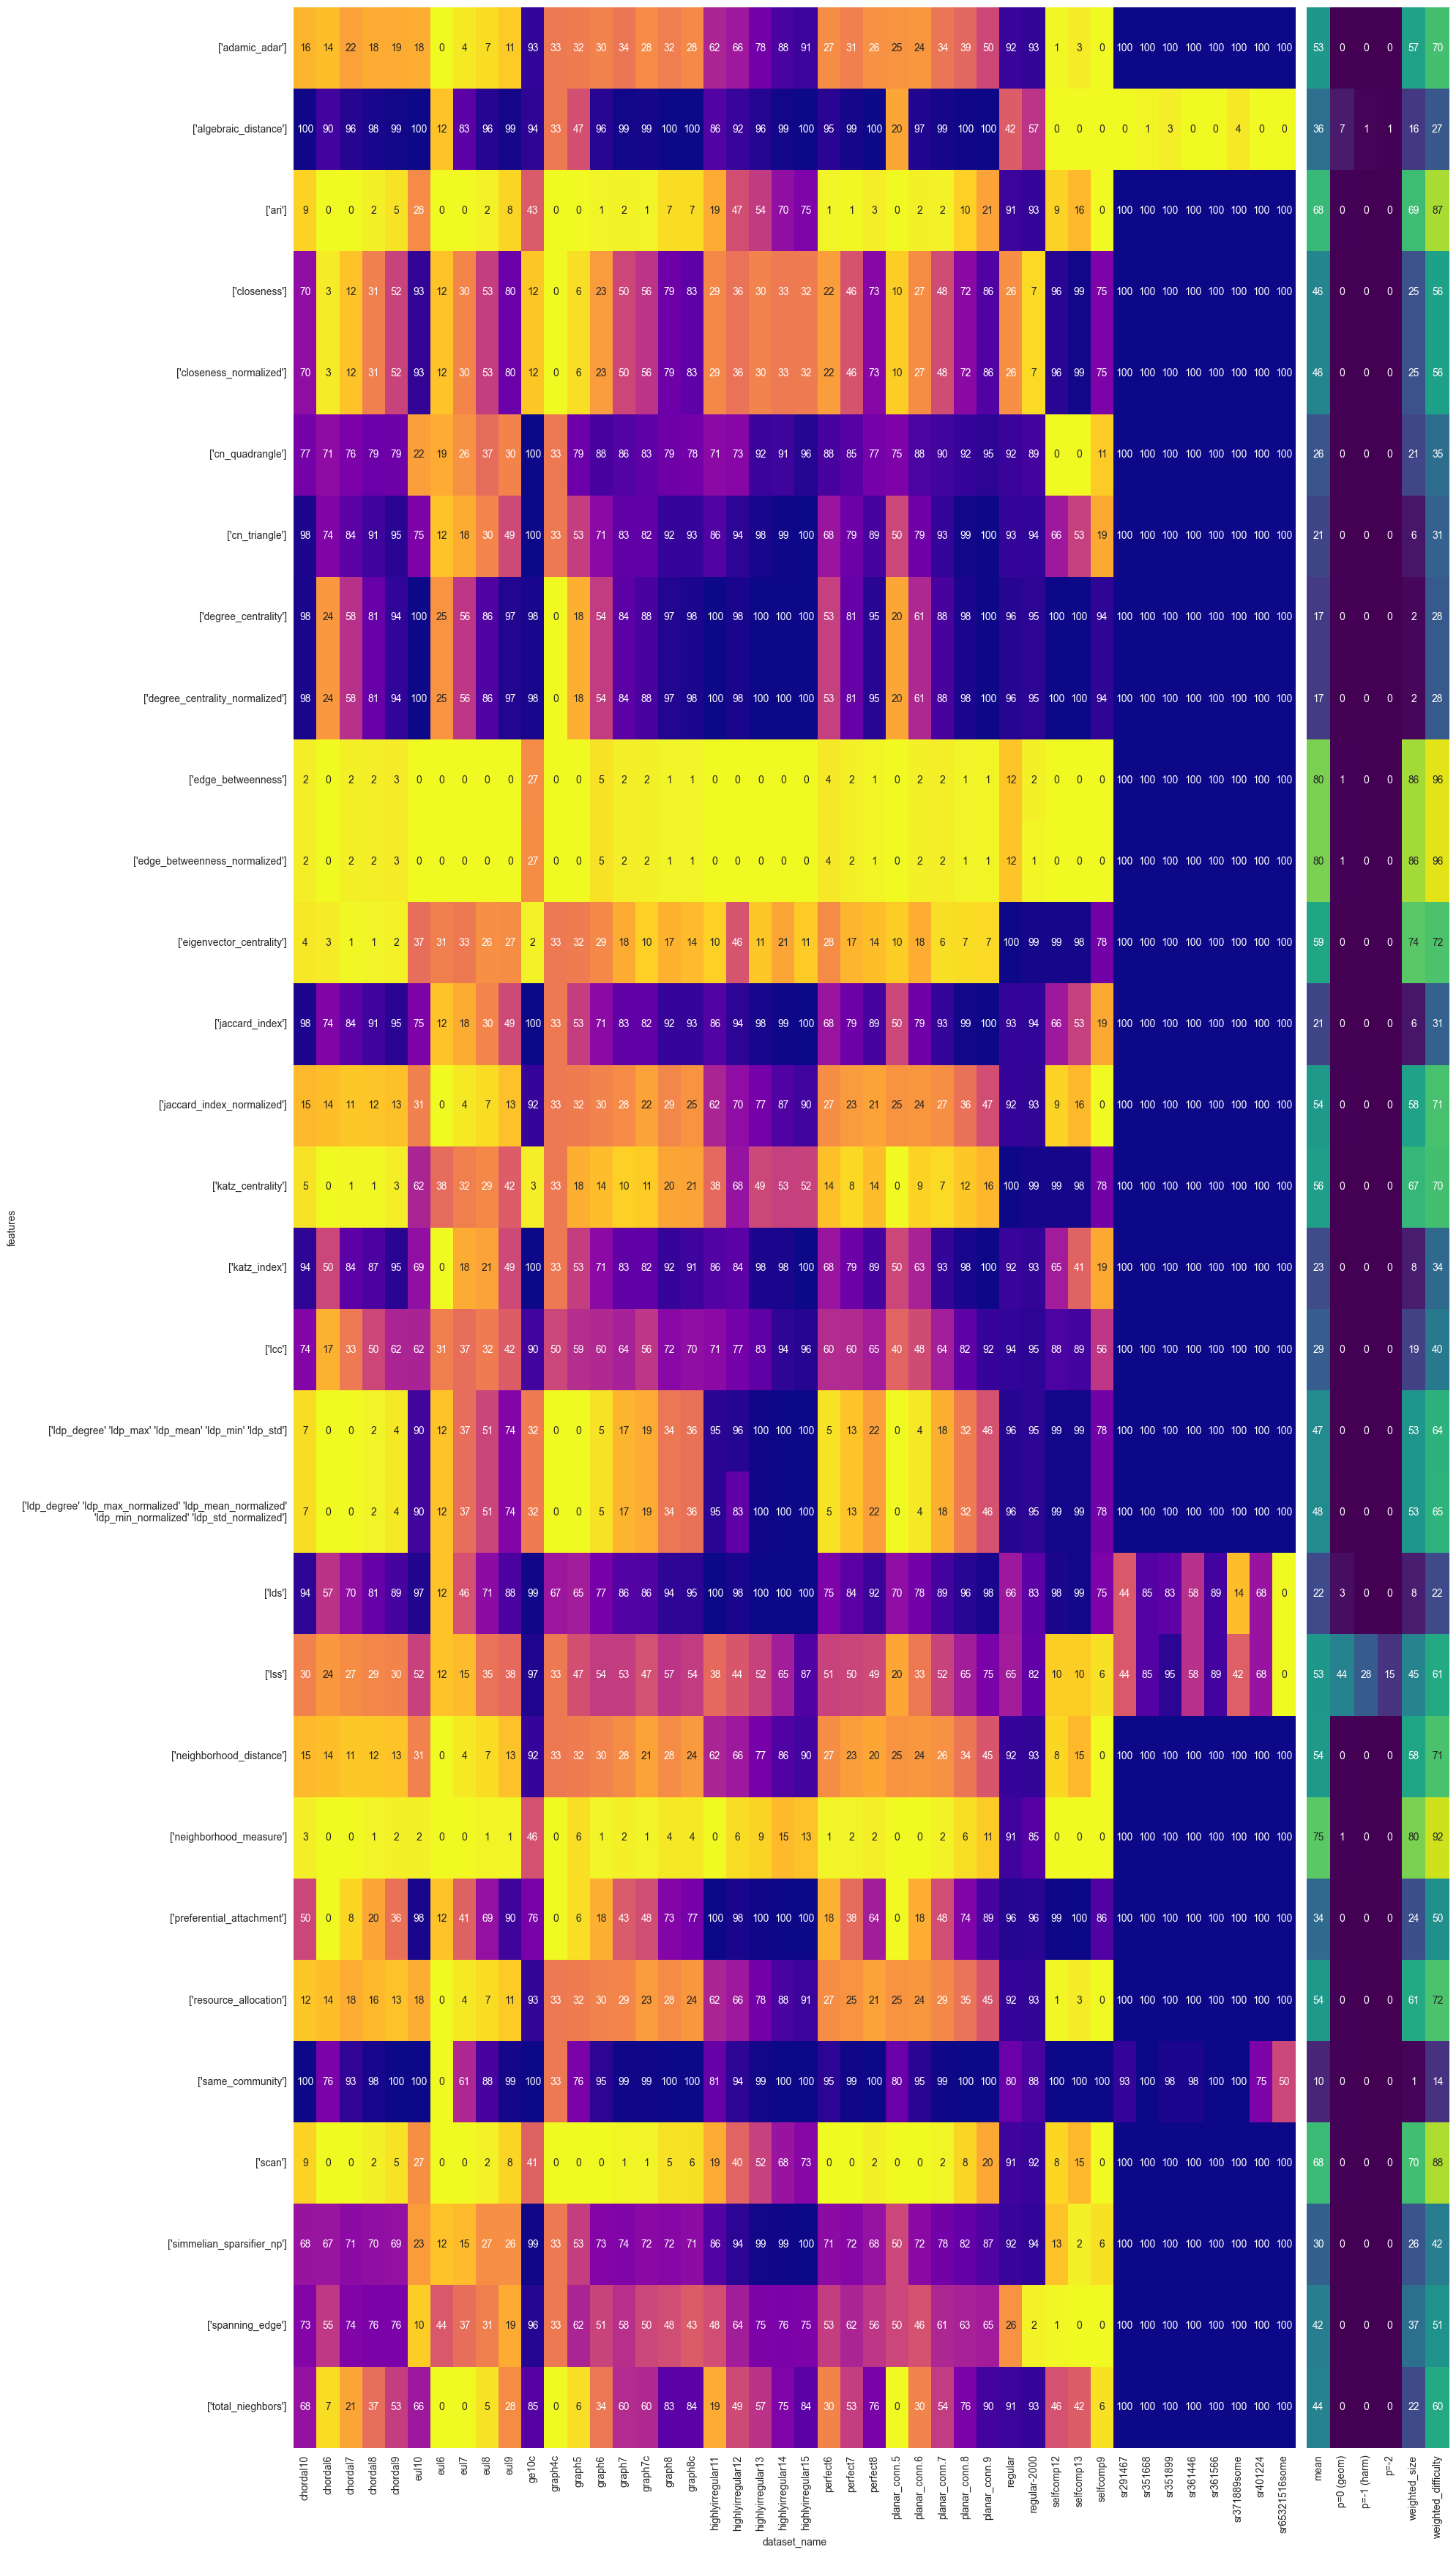

In [12]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(20, 35),
    # figsize=(20, 5),

    gridspec_kw={'width_ratios': [7, 1]}
)

sns.heatmap(
    data2d,
    cmap='plasma_r',
    vmin=0, vmax=1,
    annot=np.round(data2d * 100, 1),
    fmt=".0f",
    cbar=False,
    ax=ax1
)

sns.heatmap(
    results,
    cmap='viridis',
    vmin=0, vmax=1,
    annot=np.round(results * 100, 1),
    fmt=".0f",
    cbar=False,
    ax=ax2
)
ax2.set_yticks([])
ax2.set_ylabel("")

plt.tight_layout()

In [13]:
len(df)

30

In [14]:

# \multirow{3}{4em}{Multiple row} & cell2 & cell3 \\ 
# & cell5 & cell6 \\ 
# & cell8 & cell9 \\ 
# \hline
# \end{tabular}
# \end{center}
# '''
# latex_template

In [62]:
from typing import List
def name_to_latex(name: str) -> List:
    name = name.replace('\n', '')
    
    if name[0] != '[':
        return [name.replace('_', r'\_')]
    for s in ["[", "]", "'"]:
        name = name.replace(s, "")

    name_list: List[str] = name.split(" ")

    for i, part in enumerate(name_list):
        name_list[i] = part.replace('_', ' ')


    ltp = {"ldp degree", "ldp max", "ldp mean", "ldp min", "ldp std"}
    if len(ltp.intersection(set(name_list))) == 5:
        name_list = ["LTP"]
    if len(set(map(lambda x: x+ ' normalized' if 'degree' not in x else x, ltp)).intersection(set(name_list))) == 5:
        name_list = ["LTP normalized"]
    return name_list

def generate_latex_table(df: pd.DataFrame, bigger=True):
    
    latex_intro = rf'''
\begin{{center}}
\setlength{{\tabcolsep}}{{1.5pt}}
\renewcommand{{\arraystretch}}{{1.3}}
\tiny

\begin{{tabular}}{{ {"|l|" + "c|" * len(df.columns)} }} 
\hline
\\ & \multicolumn{{{len(df.columns)}}}{{|c|}}{{Datasets}} \\
\hline
Descriptor & { ' & '.join(map(lambda col: rf"\begin{{sideways}} {', '.join(name_to_latex(col))} \end{{sideways}}" ,df.columns)) } \\
\hline
'''

    latex_outro = rf'''
\hline
\end{{tabular}}
\end{{center}}
'''
    tex = latex_intro
    
    for row in df.iterrows():
        name = row[0]
        
        name = name_to_latex(name)
        new_line = ", ".join(name) + " & "
        
        values = np.round(row[1] , 2)
        best_score = np.argwhere(values == (np.amax(values) if bigger else np.amin(values))).flatten()
        
        def values_to_latex(x):
            i = x[0]
            x = x[1]
            return(
                (r"\cellcolor[HTML]{AAAA00}" if i in best_score else "") + 
                ('0.' if x == 0 else f"{x:.2f}".lstrip('0').replace(".00", "."))
            )
        new_line = new_line + " & ".join(map(
            values_to_latex, enumerate(values.tolist()))) + '\\\\\n'
        
        tex = tex + new_line # + "\\hline\n"
    
    tex = tex + latex_outro
    return tex


    # print(np.round(row[1] * 100, 1).astype(int))

print(generate_latex_table(df.transpose()))  


\begin{center}
\setlength{\tabcolsep}{1.5pt}
\renewcommand{\arraystretch}{1.3}
\tiny

\begin{tabular}{ |l|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c| } 
\hline
\\ & \multicolumn{30}{|c|}{Datasets} \\
\hline
Descriptor & \begin{sideways} adamic adar \end{sideways} & \begin{sideways} algebraic distance \end{sideways} & \begin{sideways} ari \end{sideways} & \begin{sideways} closeness \end{sideways} & \begin{sideways} closeness normalized \end{sideways} & \begin{sideways} cn quadrangle \end{sideways} & \begin{sideways} cn triangle \end{sideways} & \begin{sideways} degree centrality \end{sideways} & \begin{sideways} degree centrality normalized \end{sideways} & \begin{sideways} edge betweenness \end{sideways} & \begin{sideways} edge betweenness normalized \end{sideways} & \begin{sideways} eigenvector centrality \end{sideways} & \begin{sideways} jaccard index \end{sideways} & \begin{sideways} jaccard index normalized \end{sideways} & \begin{sideways} katz centrality \end{si

In [ ]:
for row in df.iterrows():
    name = row[0]
    for s in ["[", "]", "'"]:
        name = name.replace(s, "")
    name = name.replace('_', '\\_')
    name = name.split(" ")

    # TODO: ADD special handles like LTP

    new_line = " ".join(name)
    print(new_line)
    new_line = new_line + " & ".join(map(str, np.round(row[1] * 100, 1).astype(int).tolist())) + '\\'


    np.round(row[1] * 100, 1).astype(int)


    # print(" & ".join(map(str, np.round(row[1] * 100, 1).astype(int).tolist())))

adamic\_adar
83 & 86 & 78 & 81 & 81 & 81 & 100 & 96 & 93 & 88 & 6 & 66 & 67 & 69 & 65 & 72 & 68 & 71 & 38 & 33 & 21 & 12 & 8 & 73 & 69 & 73 & 75 & 75 & 65 & 61 & 50 & 8 & 6 & 99 & 96 & 100 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0
algebraic\_distance
0 & 10 & 4 & 1 & 1 & 0 & 87 & 16 & 4 & 1 & 5 & 66 & 52 & 4 & 1 & 1 & 0 & 0 & 14 & 8 & 3 & 0 & 0 & 4 & 1 & 0 & 80 & 3 & 1 & 0 & 0 & 57 & 43 & 100 & 100 & 100 & 100 & 98 & 97 & 100 & 99 & 96 & 100 & 100
ari
90 & 100 & 100 & 97 & 94 & 72 & 100 & 100 & 98 & 91 & 56 & 100 & 100 & 98 & 98 & 98 & 93 & 93 & 81 & 52 & 46 & 30 & 25 & 98 & 99 & 96 & 100 & 98 & 98 & 90 & 78 & 9 & 7 & 91 & 84 & 100 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0
closeness
29 & 96 & 87 & 69 & 48 & 6 & 87 & 70 & 46 & 20 & 88 & 100 & 94 & 76 & 50 & 43 & 20 & 17 & 71 & 64 & 69 & 66 & 67 & 77 & 54 & 27 & 90 & 72 & 51 & 28 & 13 & 73 & 92 & 4 & 0 & 25 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0
closeness\_normalized
29 & 96 & 87 & 69 & 48 & 6 & 87 & 70 & 46 & 20 & 88 & 100 & 94 & 76 & 50 & 43 & 20 & 17 & 71 & 64 

In [ ]:
print((df * 100).astype(int).to_latex())

\begin{tabular}{lrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrr}
\toprule
dataset_name & chordal10 & chordal6 & chordal7 & chordal8 & chordal9 & eul10 & eul6 & eul7 & eul8 & eul9 & ge10c & graph4c & graph5 & graph6 & graph7 & graph7c & graph8 & graph8c & highlyirregular11 & highlyirregular12 & highlyirregular13 & highlyirregular14 & highlyirregular15 & perfect6 & perfect7 & perfect8 & planar_conn.5 & planar_conn.6 & planar_conn.7 & planar_conn.8 & planar_conn.9 & regular & regular-2000 & selfcomp12 & selfcomp13 & selfcomp9 & sr291467 & sr351668 & sr351899 & sr361446 & sr361566 & sr371889some & sr401224 & sr65321516some \\
features &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  \\
\midrule
['adamic_adar'] & 83 & 86 & 78 & 81 & 81 & 81 & 100 & 96 & 93 & 88 & 6 & 66 & 67 & 69 & 65 & 72 & 68 & 71 & 38 & 33 & 21 & 12 & 8 & 72 & 69 & 73 & 75 & 75 & 65 & 61 & 50 & 7 & 6 & 99 & 96 & 100 & 0 & 0 & 0 & 0 & 0 & 0 &